In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.api import OLS, add_constant


### Note
Before, we used a value of β estimated on the whole dataset, and also mean and the std was similarly computed on the full sample. 
However, this causes an issue called "Data Leakage", as we tested on the whole sample, but we wouldn't have this information at the time of prediction and sampling, and so when we backtest, we will overestimate performance.
As a result, we must implement a rolling β value and a rolling Z-score.

In [6]:
price_data = pd.read_csv("../data/prices.csv", index_col = 0, parse_dates = True).dropna()
price_data.head()

,AAPL,MSFT
Date,,
2020-01-02,72.468277,152.505661
2020-01-03,71.763733,150.606735
2020-01-06,72.335556,150.995987
2020-01-07,71.995338,149.619263
2020-01-08,73.153503,152.002457


In [8]:
# Train/Test Split
split_date = "2022-01-01"

train = price_data.loc[:split_date] # train = model estimation
test = price_data.loc[split_date:] # test = unseen data

In [12]:
# Estimate β using a rolling window

window = 252  # 1 trading year

rolling_beta = []

# Computer a rolling regression of APPL on MSFT
for i in range(window, len(price_data)):
    y = price_data["AAPL"].iloc[i-window:i] # dependent variable : this is a subset of the AAPL prices, selecting the prices before the index i ie all prices before the i th day
    X = add_constant(price_data["MSFT"].iloc[i-window:i]) # independent variable : a subset of the MSFT prices, selecting prices similarly to AAPL, but also adding a constant such that its in the form y= mx+c
    model = OLS(y, X).fit()
    rolling_beta.append(model.params["MSFT"]) # adding the slope coeffiecient to the rolling beta list so that we can track how much AAPL moves relative to MSFT changes over time.

rolling_beta = pd.Series(
    rolling_beta,
    index=price_data.index[window:]
)

Date
2020-12-31    0.887609
2021-01-04    0.892199
2021-01-05    0.896980
2021-01-06    0.902113
2021-01-07    0.907200
dtype: float64

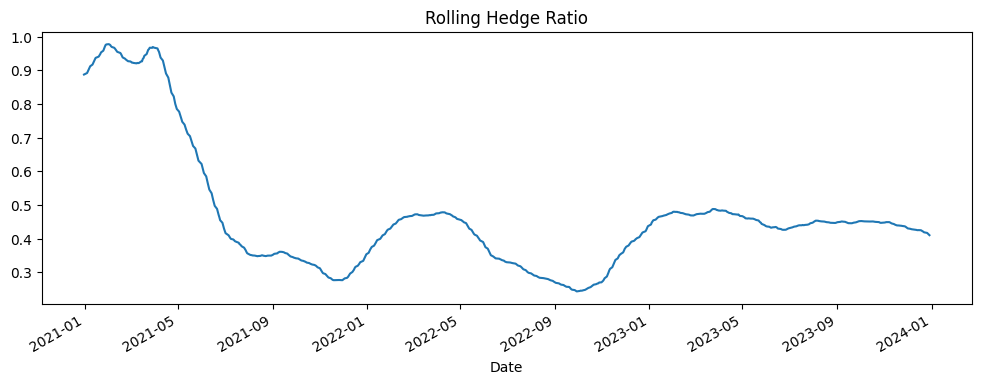

In [13]:
# Plot the estimated β against the dates ie the Rolling Hedge Ratio
rolling_beta.plot(figsize = (12,4))
plt.title("Rolling Hedge Ratio")
plt.show()

In [16]:
#Rolling Spread

aligned_prices = price_data.loc[rolling_beta.index]

spread = alligned_prices["AAPL"] - rolling_beta * aligned_prices["MSFT"]

In [17]:
# Calculate Rolling Z-Score
z_window = 60

rolling_mean = spread.rolling(z_window).mean()
rolling_std =  spread.rolling(z_window).std()

zscore = (spread - rolling_mean) / rolling_std

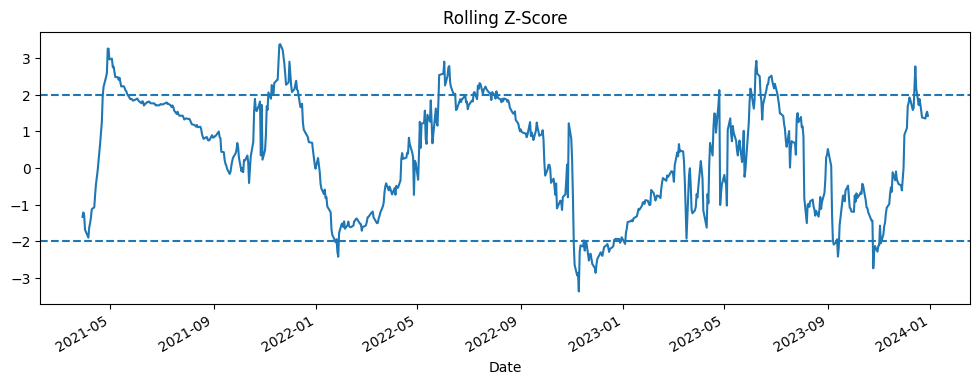

In [18]:
# Plot z-score
zscore.plot(figsize=(12,4))
plt.axhline(2, linestyle = "--")
plt.axhline(-2, linestyle = "--")
plt.title("Rolling Z-Score")
plt.show()

In [20]:
position = pd.Series(0, index = zscore.index)

position[zscore > 2] = -1
position[zscore < -2] = 1

position = position.ffill()

In [23]:
# Strategy Returns
spread_returns = spread.diff()
strategy_returns = position.shift(1) * spread_returns
strategy_returns = strategy_returns.fillna(0)


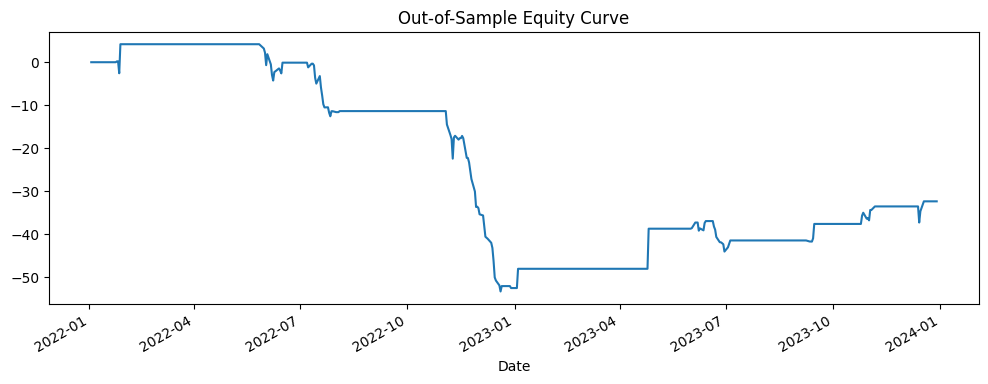

In [24]:
# Test on unseen data
strategy_test = strategy_returns.loc[test.index.intersection(strategy_returns.index)]

equity_curve = strategy_test.cumsum()

equity_curve.plot(figsize=(12,4))
plt.title("Out-of-Sample Equity Curve")
plt.show()

In [25]:
# Sharpe Ratio
mean_return = strategy_test.mean()
std_return = strategy_test.std()

sharpe = (mean_return / std_return) * np.sqrt(252)

print("Out-of-Sample Sharpe:", sharpe)


Out-of-Sample Sharpe: -1.051755975109628
